In [131]:
import os
import tarfile
import io
import numpy as np
import time
import pandas as pd
from scipy import interpolate
import pickle
import sys
from astropy.io import ascii
from astropy.table import Table
from astropy import units
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

In [2]:
decaps_cat_path = "/lustre/lrspec/users/4300/cube/Data/Phot/decaps_east.variable.parquet"
decaps_lc_path =  "/lustre/lrspec/users/4300/cube/Data/Phot/Decaps_LCs/var_curves_csv.tar.gz" #touch with caution please

In [3]:
u = pd.read_parquet(decaps_cat_path)

In [4]:
u

,varID,masterID,RA_decaps,DEC_decaps,gdr3_id,gdr3_class,ogle_id,ogle_class,asassn_id,asassn_class,vivace_id,vivace_class,RA_lit,DEC_lit,coord_source_lit,Separation,period,period_from
0,1,60077925,270.516788,-30.512758,4044156221273016448,ECL,None,None,None,None,None,None,270.516790,-30.512743,GDR3,0.052253,0.257083,GDR3
1,2,60122603,270.470358,-30.486361,4044157290673797120,ECL,OGLE-BLG-ECL-258978,ECL-C,None,None,None,None,270.470338,-30.486295,GDR3,0.246285,0.962585,OGLE4
2,2,60372642,270.470331,-30.486222,4044157290673797120,ECL,OGLE-BLG-ECL-258978,ECL-C,None,None,None,None,270.470338,-30.486295,GDR3,0.264041,0.962585,OGLE4
3,2,60372727,270.470417,-30.486147,4044157290673797120,ECL,OGLE-BLG-ECL-258978,ECL-C,None,None,None,None,270.470338,-30.486295,GDR3,0.587124,0.962585,OGLE4
4,3,60006293,270.416138,-30.480722,4044157428075090176,LPV,OGLE-BLG-LPV-181462,LPV-SRV,None,None,None,None,270.416138,-30.480692,GDR3,0.106637,268.500000,OGLE3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199016,63500,52243284,270.567007,-30.051091,None,None,None,None,ASASSN-V J180216.08-300303.7,SR,None,None,270.566994,-30.051032,ASASSN,0.218767,147.000000,ASASSN
199017,63501,45240178,270.065065,-29.919359,None,None,None,None,ASASSN-V J180015.62-295509.5,SR,None,None,270.065067,-29.919298,ASASSN,0.216858,312.000000,ASASSN
199018,63502,44239139,271.776647,-29.705144,None,None,None,None,ASASSN-V J180706.40-294218.4,SR,None,None,271.776657,-29.705107,ASASSN,0.137179,492.000000,ASASSN
199019,63503,38212333,271.876784,-29.673771,None,None,None,None,ASASSN-V J180730.43-294025.4,SR,None,None,271.876796,-29.673730,ASASSN,0.152088,278.000000,ASASSN


In [5]:
u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199021 entries, 0 to 199020
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   varID             199021 non-null  int64  
 1   masterID          199021 non-null  int64  
 2   RA_decaps         199021 non-null  float64
 3   DEC_decaps        199021 non-null  float64
 4   gdr3_id           70518 non-null   object 
 5   gdr3_class        70518 non-null   object 
 6   ogle_id           130417 non-null  object 
 7   ogle_class        130417 non-null  object 
 8   asassn_id         60 non-null      object 
 9   asassn_class      60 non-null      object 
 10  vivace_id         50929 non-null   object 
 11  vivace_class      50929 non-null   object 
 12  RA_lit            199021 non-null  float64
 13  DEC_lit           199021 non-null  float64
 14  coord_source_lit  199021 non-null  object 
 15  Separation        199021 non-null  float64
 16  period            17

In [14]:
u = u[u["gdr3_class"] != "WD"]

In [20]:
classes = set(u["gdr3_class"]) | set(u["ogle_class"]) | set(u["asassn_class"]) | set(u["vivace_class"])
classes.remove(None)
print(classes)

{'RRLyr-RRc', 'LPV-OSARG', 'DSCT|GDOR|SXPHE', 'LPV-SRV', 'ECL', 'DSCT-multimode', 'T2Cep-BLHer', 'ECL-C', 'RRLyr-RRab', 'Cep-F', 'ELL', 'SR', 'S', 'RR', 'CEP', 'ECL-NC', 'RRLyr-aRRd', 'ROT', 'LPV-Mira', 'aCep-F', 'T2CEP', 'LPV', 'RS', 'RRLyr-RRd', 'YSO', 'L', 'SOLAR_LIKE', 'SYST', 'HB-RG', 'RRab', 'HB-MS', 'Ell', 'EA', 'Cep-1', 'BE|GCAS|SDOR|WR', 'M', 'T2Cep-RVTau', 'RRcd', 'T2Cep-WVir', 'ACV|CP|MCP|ROAM|ROAP|SXARI', 'DSCT-singlemode', 'ECL-ELL', 'HADS', 'EA/EB', 'EW'}


In [12]:
print(len(u))

199021


In [22]:
u[u[["gdr3_class", "ogle_class","asassn_class","vivace_class"]].isin(["ROT"]).any(axis=1)]

,varID,masterID,RA_decaps,DEC_decaps,gdr3_id,gdr3_class,ogle_id,ogle_class,asassn_id,asassn_class,vivace_id,vivace_class,RA_lit,DEC_lit,coord_source_lit,Separation,period,period_from
199015,63499,58231564,271.067456,-30.308194,None,None,None,None,ASASSN-V J180416.18-301829.0,ROT,None,None,271.067436,-30.308048,ASASSN,0.528586,5.1271,ASASSN


In [33]:
for type in list(classes):
    u_filt = u[u[["gdr3_class", "ogle_class","asassn_class","vivace_class"]].isin([type]).any(axis=1)]
    print(f"Number of {type}: {len(u_filt)}")

Number of RRLyr-RRc: 1161
Number of LPV-OSARG: 39305
Number of DSCT|GDOR|SXPHE: 761
Number of LPV-SRV: 6313
Number of ECL: 25566
Number of DSCT-multimode: 662
Number of T2Cep-BLHer: 32
Number of ECL-C: 16146
Number of RRLyr-RRab: 2444
Number of Cep-F: 1
Number of ELL: 4398
Number of SR: 55
Number of S: 644
Number of RR: 3228
Number of CEP: 99
Number of ECL-NC: 56373
Number of RRLyr-aRRd: 6
Number of ROT: 1
Number of LPV-Mira: 1586
Number of aCep-F: 5
Number of T2CEP: 61
Number of LPV: 35874
Number of RS: 518
Number of RRLyr-RRd: 19
Number of YSO: 36
Number of L: 1
Number of SOLAR_LIKE: 136
Number of SYST: 19
Number of HB-RG: 135
Number of RRab: 2298
Number of HB-MS: 2
Number of Ell: 6040
Number of EA: 1
Number of Cep-1: 8
Number of BE|GCAS|SDOR|WR: 1
Number of M: 1
Number of T2Cep-RVTau: 13
Number of RRcd: 819
Number of T2Cep-WVir: 18
Number of ACV|CP|MCP|ROAM|ROAP|SXARI: 8
Number of DSCT-singlemode: 1073
Number of ECL-ELL: 5115
Number of HADS: 1
Number of EA/EB: 26496
Number of EW: 14

In [37]:
my_types = {
    "Delta_sct": ["DSCT-multimode", "DSCT-singlemode", "HADS", "DSCT|GDOR|SXPHE"],
    "Ecl_ell": ["ELL", "ECL-ELL", "Ell","HB-RG","HB-MS"],
    "RRLyr": ["RRcd", "RRab", "RRLyr-RRd", "RR", "RRLyr-RRab", "RRLyr-RRc"],
    "Cep": ["Cep-1","CEP", "Cep-F", "T2Cep-WVir", "T2Cep-RVTau", "T2CEP", "T2Cep-BLHer"],
    "LPV" : ["M", "LPV", "LPV-Mira", "LPV-SRV", "LPV-OSARG"],
    "Mira" : ["M", "LPV-Mira"],
    "Type2_Cep" : ["T2Cep-WVir", "T2Cep-RVTau", "T2CEP", "T2Cep-BLHer"],
    "Ecl" : ["EA/EB","EW","EA","ECL-NC","ECL-C","ECL"]
}

In [38]:
my_types["LPV"]

['M', 'LPV', 'LPV-Mira', 'LPV-SRV', 'LPV-OSARG']

In [42]:
for type in my_types:
    length = 0
    u_filt = u[u[["gdr3_class", "ogle_class","asassn_class","vivace_class"]].isin(my_types[type]).any(axis=1)]
    length = length + len(u_filt)
    print(f"Number of {type}: {length}")

Number of Delta_sct: 2494
Number of Ecl_ell: 13964
Number of RRLyr: 4428
Number of Cep: 118
Number of LPV: 64575
Number of Mira: 1587
Number of Type2_Cep: 81
Number of Ecl: 113610


In [43]:
u_Cep = u[u[["gdr3_class", "ogle_class","asassn_class","vivace_class"]].isin(my_types["Cep"]).any(axis=1)]

In [46]:
u_Cep["varID"]

10286      3328
10499      3400
10500      3400
10501      3400
12570      4022
          ...  
192459    61586
192460    61586
192461    61586
192462    61586
192463    61586
Name: varID, Length: 118, dtype: int64

In [9]:
u[u["masterID"]==8048865]

,varID,masterID,RA_decaps,DEC_decaps,gdr3_id,gdr3_class,ogle_id,ogle_class,asassn_id,asassn_class,vivace_id,vivace_class,RA_lit,DEC_lit,coord_source_lit,Separation,period,period_from
78293,25307,8048865,270.028726,-28.910224,None,None,OGLE-BLG-ECL-239319,ECL-NC,None,None,None,None,270.02871,-28.910167,OGLE4,0.210103,0.566176,OGLE4


LC file names: varID.csv

In [10]:
# varID = 1
# LC_file_name = f"{varID}.csv"

In [64]:
files = []
for ID in u_Cep["varID"]:
    files.append(str(ID)+".csv")
print(len(files))
print(len(u_Cep["varID"]))

118
118


In [153]:
%%time
with tarfile.open(decaps_lc_path,"r|gz") as tar:
    dfs = []
    keys = []
    for member in tar:
        if member.name in files[0:10]:
            # csv_file = io.StringIO(tar.extractfile(f"{varID}.csv").read().decode('ascii'))
            csv_file = io.StringIO(tar.extractfile(member).read().decode('ascii'))
            df = pd.read_csv(csv_file)
            df["varID"] = member.name.removesuffix(".csv")
            dfs.append(df)
            
    # for varID in u_Cep["varID"]:
    #     csv_file = io.StringIO(tar.extractfile(f"{varID}.csv").read().decode('ascii'))
    #     df = pd.read_csv(csv_file)
    #     dfs.append(df)
    
df_Cep = pd.concat(dfs, ignore_index = True)

CPU times: user 38.6 s, sys: 706 ms, total: 39.3 s
Wall time: 39.3 s


^ This is also really slow and idk what to do about that at this point because it's just a massive tar file

In [20]:
#q = pd.read_csv(f"/lustre/lrspec/users/4300/cube/Data/Phot/Decaps_LCs/{LC_file_name}")

In [154]:
print(len(dfs))

6


In [155]:
df_Cep.head()

,MJD,M,dM,flux,dflux,type,Band,masterID,varID
0,59361.335000,13.8640,0.001,266776.28,345.51,1,g,31205613,3328
1,59352.296123,13.5452,0.001,329954.22,322.32,1,g,31205613,3328
2,59346.355669,-112.3710,0.001,223132.64,252.02,1,g,31205613,3328
3,59705.357160,13.4921,0.001,715403.88,449.10,1,g,31205613,3328
4,59319.417170,13.5815,0.001,341390.88,288.28,1,g,31205613,3328


(array([  75.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        7375.]),
 array([-115.111  , -101.79903,  -88.48706,  -75.17509,  -61.86312,
         -48.55115,  -35.23918,  -21.92721,   -8.61524,    4.69673,
          18.0087 ]),
 <BarContainer object of 10 artists>)

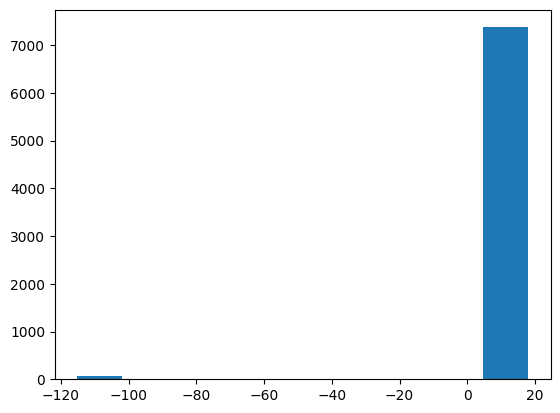

In [156]:
plt.hist(df_Cep["M"])

In [163]:
df_Cep = df_Cep[df_Cep["M"]>0].reset_index(drop=True)

In [190]:
pref_dT1s = np.arange(-480, 481, 15)
pref_dT2s = np.hstack(( np.arange(-1920, -1439, 30), np.arange(-480, 481, 30), np.arange(1440, 1921, 30) )) 
#pref_dT1s = np.arange(-480, 481, 1)
#pref_dT2s = np.hstack((np.arange(-480, 481, 1))) 
thrs = {'u': 23.9, 'g': 25.0, 'r': 24.7, 'i': 24.0, 'z': 23.3, 'y': 22.1}

In [191]:
print(np.unique(df_Cep["Band"]))

['g' 'i' 'r' 'z']


In [192]:
df_Cep

,MJD,M,dM,flux,dflux,type,Band,masterID,varID
0,59361.335000,13.8640,0.001,266776.28,345.51,1,g,31205613,3328
1,59352.296123,13.5452,0.001,329954.22,322.32,1,g,31205613,3328
2,59705.357160,13.4921,0.001,715403.88,449.10,1,g,31205613,3328
3,59319.417170,13.5815,0.001,341390.88,288.28,1,g,31205613,3328
4,59708.357288,13.7826,0.001,625157.19,436.58,1,g,31205613,3328
...,...,...,...,...,...,...,...,...,...
7370,60079.379602,13.2305,0.002,196665.33,311.01,1,z,27088788,4658
7371,60134.242911,13.2767,0.002,255633.77,383.51,1,z,27088788,4658
7372,60076.371336,13.2583,0.001,255962.55,288.49,1,z,27088788,4658
7373,60487.285837,13.1242,0.002,1723568.25,2715.87,1,z,27088788,4658


In [193]:
obj_dfs = []

for n, obj in enumerate(np.unique(df_Cep["varID"])):
    timepairs = []
    bandpairs = []
    dMags = []
    colors = []
    name = []
    df_obj = df_Cep[df_Cep["varID"]==obj].reset_index(drop=True)
    
    for i,mjd1 in enumerate(df_obj["MJD"]):
        dT1s2 = []
        dT2s2 = []
        dMs = []
        bps = []
        cs = []
        for j, mjd2 in enumerate(df_obj["MJD"]):
            if df_obj["Band"][i] != df_obj["Band"][j]:
                dT1 = -(mjd1-mjd2)*units.day
                dT1 = int((dT1.to(units.min)/units.min))

                
                if dT1 in pref_dT1s:
                    M1 = df_obj["M"][i]
                    M2 = df_obj["M"][j]
                    # M1 = -2.5*np.log10(dp2_obj["psfFlux"][i])+31.4
                    # M2 = -2.5*np.log10(dp2_obj["psfFlux"][j])+31.4
                    color = M1-M2
                    #= dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j]
                    BandPair = df_obj["Band"][i]+df_obj["Band"][j]
                        
                    
                    dT1s2.append(dT1)
                    cs.append(color)
                    bps.append(BandPair)
            
            else:
                dT2 = -(mjd1-mjd2)*units.day
                dT2 = int((dT2.to(units.min)/units.min))

                
                if dT2 in pref_dT2s and dT2 != 0:
                    M1 = df_obj["M"][i]
                    M2 = df_obj["M"][j]
                    
                    # M1 = -2.5*np.log10(dp2_obj["psfFlux"][i])+31.4
                    # M2 = -2.5*np.log10(dp2_obj["psfFlux"][j])+31.4
                    
                    # dflux = (dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j])
    
                    dT2s2.append(dT2)
                    #dMs.append((-2.5*np.log10(dflux))*np.sign(dT2))
                    dMs.append((M1-M2)*np.sign(dT2))
            
        for k, dT1 in enumerate(dT1s2):
            for h, dT2 in enumerate(dT2s2):
                timepairs.append((dT1,dT2))

                bandpairs.append(bps[k])
                colors.append(cs[k])
                
                dMags.append(dMs[h])

                name.append(obj)
                    

    obj_pts = pd.DataFrame()
    obj_pts["Timepairs"] = timepairs
    obj_pts["dMags"] = dMags
    obj_pts["Colors"] = colors
    obj_pts["Bandpairs"] = bandpairs
    obj_pts["Object Name"] = name

    obj_dfs.append(obj_pts)

    print(f'{n+1} of {len(np.unique(df_Cep["varID"]))}')
print("Done!")

1 of 6
2 of 6
4 of 6
5 of 6
6 of 6
Done!


In [200]:
print(len(obj_dfs[5]))

15


In [208]:
to_be_cubed = pd.concat(obj_dfs,ignore_index = True)

In [209]:
to_be_cubed

,Timepairs,dMags,Colors,Bandpairs,Object Name
0,"(45, 30)",0.1384,1.8123,gi,3328
1,"(45, 30)",-0.0175,1.3996,gi,3400
2,"(0, 90)",-0.0571,2.0519,gz,3400
3,"(-75, -90)",-0.0589,1.8348,gi,3400
4,"(15, -30)",-0.0175,1.7954,gz,3400
...,...,...,...,...,...
53434,"(-15, 90)",0.1532,0.4327,iz,4658
53435,"(-120, -90)",0.1532,-2.4244,ig,4658
53436,"(-105, -90)",0.1532,0.2795,iz,4658
53437,"(15, 30)",0.0080,-2.2470,ig,4658


In [215]:
to_be_cubed["Timepairs"][][0]

45

In [219]:
print(len(np.unique(to_be_cubed["Timepairs"])))

2118


In [220]:
print(len(pref_dT1s)*len(pref_dT2s))

4355


In [221]:
print(np.unique(to_be_cubed["Bandpairs"]))

['gi' 'gr' 'gz' 'ig' 'ir' 'iz' 'rg' 'ri' 'rz' 'zg' 'zi' 'zr']


In [273]:
dT1s = []
dT2s = []
for bp in np.unique(to_be_cubed["Timepairs"]):
    dT1s.append(bp[0])
    dT2s.append(bp[1])
dT1s = np.unique(dT1s)
dT2s = np.unique(dT2s)

In [274]:
dT1s2 = np.arange(-480, 481, 15)

In [276]:
print(len(dT1s), len(dT1s2))

65 65


In [320]:
Bands = ['g', 'r', 'i', 'z']

#dT1s = np.arange(-480, 481, 15)
#dT2s = np.hstack(( np.arange(-1920, -1439, 30), np.arange(-480, 481, 30), np.arange(1440, 1921, 30) )) 

BinMag = np.arange(-5.05, 6.0, 0.1)
BinColor = np.arange(-9.25, 9.8, 0.5)

Thrs = {'u': 23.9, 'g': 25.0, 'r': 24.7, 'i': 24.0, 'z': 23.3, 'Y': 22.1}

BandPairs = np.unique(to_be_cubed["Bandpairs"])
TimePairs = np.unique(to_be_cubed["Timepairs"])


HashTableDim = [ len(BandPairs), len(TimePairs), len(BinMag)-1, len(BinColor)-1 ]
print(len(TimePairs))


2118


In [321]:
BandPair = "gr"

In [322]:
BandPairs2 = [B1+B2 for B1 in Bands for B2 in Bands if B1!=B2 and B1+B2!='uY' and B1+B2!='Yu']
list(BandPairs).type

AttributeError: 'list' object has no attribute 'type'

In [323]:
to_be_cubed2["Timepairs"]

5       (-105, -90)
7        (-75, -60)
10      (-15, 1440)
11      (-15, 1440)
183      (90, -270)
           ...     
7046      (-60, 90)
7063      (60, 180)
7081    (-15, 1440)
7086    (-15, 1440)
7087    (-90, -180)
Name: Timepairs, Length: 1927, dtype: object

In [324]:
# def CalculateMap(BandPair, FilePath,
#                  TimePairs=TimePairs,  
#                  BinMag=BinMag, BinColor=BinColor,
#                  HashTableDim=HashTableDim, 
#                  Objects=Objects, PointsPerDay=PointsPerDay, Thrs=Thrs):
    
Band1 = BandPair[0]
Band2 = BandPair[1]   

print(BandPair)

to_be_cubed2 = to_be_cubed[to_be_cubed["Bandpairs"] == BandPair]

    
Objects = np.unique(to_be_cubed2["Object Name"])

HashTable = np.zeros(HashTableDim[1:], dtype=np.uint32)
print(HashTable(

for kk, TimePair in enumerate(TimePairs):
    # print(kk+1,"of",len(TimePairs), TimePair)
    dT1 = TimePair[0]
    dT2 = TimePair[1]

    dMag = []
    Color = []

    dMagMin = []
    dMagMax = []
    ColorMin = []
    ColorMax = []


    #Calculate the values of the functions with selected x values.  
    dMag = to_be_cubed2["dMags"][to_be_cubed2["Timepairs"]==TimePair]
    if len(dMag) == 0:
        continue
    Color = to_be_cubed2["Colors"][to_be_cubed2["Timepairs"]==TimePair]
        
    # data = np.array([dMag, Color])
    histdata,_,_ = np.histogram2d(dMag, Color, bins=[BinMag, BinColor])

    dMagMin.append(min(dMag))
    dMagMax.append(max(dMag))
    ColorMin.append(min(Color))
    ColorMax.append(max(Color))

    outliersNo = len(dMag) - int(histdata.sum())

    HashTable[kk] = histdata

    # if kk == 1000 or kk == len(TimePairs)-1:
    #     print("Step 3")
# return  [len(Objects), BandPair, outliersNo, min(dMagMin), max(dMagMax), min(ColorMin), max(ColorMax)], HashTable

gr


In [337]:
print(len(TimePairs))

2118


In [343]:
print(len(HashTable[:,0]))

2118


In [315]:
def Enquiry(HashTable, InfoDict, Band1, Band2, dT1, dT2, dMag=None, Color=None):
    if abs(dT1) > abs(dT1-dT2):
        dT1, dT2 = dT1-dT2, -dT2    
    Ind1 = InfoDict['BandPairs'].index(Band1+Band2)
    #index for where 1st filter is, 2nd index for 2nd filter
    dT1grid = InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ]
    dT2grid = InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ]
    
    TimePairGrid = np.array([ InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ], InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ] ])
    print(np.array(InfoDict['TimePairs']),TimePairGrid )
    # above will need some difference to set limit on difference in times
    Ind2 = np.where( (np.array(InfoDict['TimePairs']) == TimePairGrid ).all(axis=1) )[0][0]
    print(len(HashTable[0,:]))
    Results = HashTable[Ind1, Ind2]

    if dMag == None:
        pass        
    elif dMag<InfoDict['BinMag'][0] or dMag>=InfoDict['BinMag'][-1]:
        raise ValueError('The value of dMag is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinMag'][0], InfoDict['BinMag'][-1]))        
    else:
        Results = Results[np.where( dMag >= InfoDict['BinMag'] )[0][-1]]       

    if Color == None:
        pass        
    elif Color<InfoDict['BinColor'][0] or Color>=InfoDict['BinColor'][-1]:
        raise ValueError('The value of Color is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinColor'][0], InfoDict['BinColor'][-1]))
        
    else:
        Results = Results[..., np.where( Color >= InfoDict['BinColor'] )[0][-1] ]

    return Results

In [316]:
def PlotSlice(HashTable1, InfoDict1, Band1, Band2, dT1, dT2, ax = None):
    # cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))
    
    if ax == None: 
        fig, ax = plt.subplots(1,1)

    

    Map1 = Enquiry(HashTable1, InfoDict1, Band1, Band2, dT1, dT2) * 10000000

    ax.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
                        norm=LogNorm(1, vmax=Map1.max()+1), cmap="gist_grey")

        # ax.scatter(Data[0], Data[1], c='mediumpurple', s=1, alpha=0.1, )


    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-5, 8]) 


In [319]:
HashTableTotal = np.zeros(HashTableDim, dtype=np.uint32)
HashTableTotal[list(BandPairs).index(BandPair)] = HashTable

InfoDict = {}
InfoDict['EventName'] = "Cepheid"
InfoDict['PointsPerDay'] = "N/A"
InfoDict['ObjectNo'] = len(Objects)

InfoDict['BandPairs'] = [ii.lower() for ii in BandPairs]

InfoDict['dT1s'] = dT1s
InfoDict['dT2s'] = dT2s

InfoDict['BinMag'] = BinMag
InfoDict['BinColor'] = BinColor

InfoDict['dMagRange'] = [ min(dMagMin), max(dMagMax) ]
InfoDict['ColorRange'] = [ min(ColorMin), max(ColorMax) ]

infdict_tps = []
for pair in np.unique(to_be_cubed["Timepairs"]):
    infdict_tps.append(list(pair))
InfoDict['TimePairs'] = infdict_tps
print(len(infdict_tps))


if outliersNo>0:
    InfoDict['Outliers'] = outliersNo
    InfoDict['OutliersRatio'] = outliersNo / HashTableTotal.max()        

if HashTableTotal.min()<0:
    InfoDict['Overflow'] = HashTableTotal.min()

2118


In [355]:
import os
import numpy as np
import time
from scipy import interpolate
import pickle
import sys


TargetFolder = '/lustre/lrspec/users/4300/cube/Data/Datacube/DECaPS_VS'


EventNames = ['Ceph']


Bands = ['g', 'r', 'i', 'z']

#dT1s = np.arange(-480, 481, 15)
#dT2s = np.hstack(( np.arange(-1920, -1439, 30), np.arange(-480, 481, 30), np.arange(1440, 1921, 30) )) 

BinMag = np.arange(-5.05, 6.0, 0.1)
BinColor = np.arange(-9.25, 9.8, 0.5)

Thrs = {'u': 23.9, 'g': 25.0, 'r': 24.7, 'i': 24.0, 'z': 23.3, 'Y': 22.1}

BandPairs = np.unique(to_be_cubed["Bandpairs"])
TimePairs = np.unique(to_be_cubed["Timepairs"])


HashTableDim = [ len(BandPairs), len(TimePairs), len(BinMag)-1, len(BinColor)-1 ]


def CalculateMap(BandPair,
                 TimePairs=TimePairs,  
                 BinMag=BinMag, BinColor=BinColor,
                 HashTableDim=HashTableDim, 
                 Objects=Objects, PointsPerDay="N/A", Thrs=Thrs):
    
    Band1 = BandPair[0]
    Band2 = BandPair[1]   
    
    
    to_be_cubed2 = to_be_cubed[to_be_cubed["Bandpairs"] == BandPair]
    
        
    Objects = np.unique(to_be_cubed2["Object Name"])
    
    HashTable = np.zeros(HashTableDim[1:], dtype=np.uint32)
    dMagMin = []
    dMagMax = []
    ColorMin = []
    ColorMax = []
    
    for kk, TimePair in enumerate(TimePairs):
        # print(kk+1,"of",len(TimePairs), TimePair)
        dT1 = TimePair[0]
        dT2 = TimePair[1]
    
        dMag = []
        Color = []
    
        #Calculate the values of the functions with selected x values.  
        dMag = to_be_cubed2["dMags"][to_be_cubed2["Timepairs"]==TimePair]

        if len(dMag) == 0:
            continue
        Color = to_be_cubed2["Colors"][to_be_cubed2["Timepairs"]==TimePair]
            
        # data = np.array([dMag, Color])
        histdata,_,_ = np.histogram2d(dMag, Color, bins=[BinMag, BinColor])
    
        dMagMin.append(min(dMag))
        dMagMax.append(max(dMag))
        ColorMin.append(min(Color))
        ColorMax.append(max(Color))

        outliersNo = len(dMag) - int(histdata.sum())
    
        HashTable[kk] = histdata

    return  [len(Objects), BandPair, outliersNo, min(dMagMin), max(dMagMax), min(ColorMin), max(ColorMax)], HashTable


def reduceAndSave(results, EventName, HashTableDim=HashTableDim, 
                  BandPairs=BandPairs, dT1s=dT1s, dT2s=dT2s, TimePairs=TimePairs, 
                  BinMag=BinMag, BinColor=BinColor, PointsPerDay="N/A", TargetFolder=TargetFolder):
    
    HashTableTotal = np.zeros(HashTableDim, dtype=np.uint32)
    
    outliersNo = 0
    dMagMin = []
    dMagMax = []
    ColorMin = []
    ColorMax = []
    
    for info, HashTable in results:
        
        HashTableTotal[list(BandPairs).index(info[1])] = HashTable
        outliersNo += info[2]
        dMagMin.append(info[3])
        dMagMax.append(info[4])
        ColorMin.append(info[5])
        ColorMax.append(info[6])
        
    InfoDict = {}
    InfoDict['EventName'] = EventName
    InfoDict['PointsPerDay'] = PointsPerDay
    InfoDict['ObjectNo'] = results[0][0][0]

    InfoDict['BandPairs'] = [ii.lower() for ii in list(BandPairs)]

    InfoDict['dT1s'] = dT1s
    InfoDict['dT2s'] = dT2s

    InfoDict['BinMag'] = BinMag
    InfoDict['BinColor'] = BinColor

    InfoDict['dMagRange'] = [ min(dMagMin), max(dMagMax) ]
    InfoDict['ColorRange'] = [ min(ColorMin), max(ColorMax) ]

    infdict_tps = []
    for pair in np.unique(to_be_cubed["Timepairs"]):
        infdict_tps.append(list(pair))
    InfoDict['TimePairs'] = infdict_tps

    
    if outliersNo>0:
        InfoDict['Outliers'] = outliersNo
        InfoDict['OutliersRatio'] = outliersNo / HashTableTotal.max()        
    
    if HashTableTotal.min()<0:
        InfoDict['Overflow'] = HashTableTotal.min()
        
    #Save results

    FileName = 'ProbCube_' + time.strftime('%m%d_%H%M') + '__' + EventName + '.pkl'

    FilePath = os.path.join(TargetFolder, FileName)
    FilePath0 = FilePath

    ii = 1
    while os.path.exists(FilePath):
        FilePath = FilePath0[:-4] + '('+str(ii)+')' + '.pkl'
        ii += 1

    # with open(FilePath, 'wb') as f:
    #     pickle.dump(InfoDict, f)
    #     pickle.dump(HashTableTotal, f ) 
    return InfoDict, HashTableTotal

for EventName in EventNames:
    results = []
    for z, BandPair in enumerate(BandPairs):
        print(f'{z+1} of {len(BandPairs)}, {BandPair}')
        results.append(CalculateMap(BandPair))
    InfoDict, HashTable1 = reduceAndSave(results, EventName)

print('###############\nFinish!\n###############')

1 of 12, gi
2 of 12, gr
3 of 12, gz
4 of 12, ig
5 of 12, ir
6 of 12, iz
7 of 12, rg
8 of 12, ri
9 of 12, rz
10 of 12, zg
11 of 12, zi
12 of 12, zr
###############
Finish!
###############


In [367]:
to_be_cubed[to_be_cubed["Bandpairs"] == "ir"]["Timepairs"]

35311    (-330, -270)
35312    (-330, -150)
35313    (-330, -180)
35314    (-330, -210)
35315    (-330, -240)
             ...     
44829    (-120, -180)
44830     (-120, -90)
44831    (-165, -180)
44832     (-165, -90)
44847      (15, 1440)
Name: Timepairs, Length: 3625, dtype: object

[[ -480 -1920]
 [ -480 -1890]
 [ -480 -1860]
 ...
 [  480   240]
 [  480   270]
 [  480   300]] [  15 1440]
2118


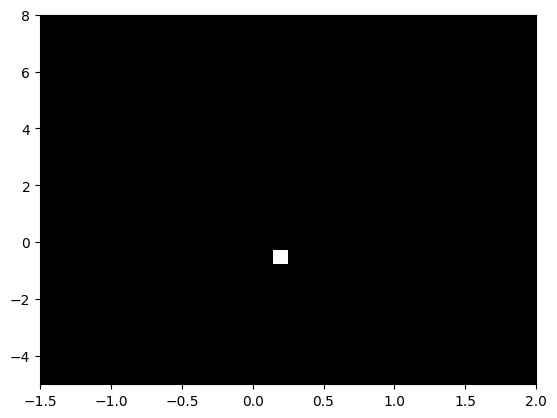

In [368]:
PlotSlice(HashTable1, InfoDict, "i","r",15,1440)

In [370]:
test = pd.read_parquet("/lustre/lrspec/users/4300/cube/Data/Phot/Decaps_LCs/Cep_DECaPS.parquet.gzip")

In [372]:
len(np.unique(test["varID"]))

42